## Import libraries and packages

In [1]:
# import libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# import pickle for handing off
import pickle

## Preprocessing

In [2]:
def build_dataframe(mat, time):
    '''
    Constructs dataframe from an edgelist created using a matrix for a defined timestamp.
    '''
    edges = []
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if i == j:
                continue
                
            val = int(mat[i, j])
            if val in [0, 4, 6, 9]:
                continue

            if val in [1,2,3]:
                sign = +1
                
            elif val == 5:
                sign = -1
            edges.append((i+1, j+1, sign, time))
    df = pd.DataFrame(edges, columns=['from', 'to', 'sign', 'time'])
    return df

In [3]:
def load_dutch():
    '''
    loads the Van de Bunt Dutch College dataset.
    '''
    df_list = []
    for t in range(1,7):
        mat = np.loadtxt(f'../data/processed/vdBunt_data/VRND32T{t}.DAT')
        df = build_dataframe(mat, f't{t}') 
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

def load_frat():
    '''
    loads the Newcomb Fraternity dataset.
    '''
    df_list = []
    for t in range(16):
        if t == 9: 
            continue
        df = pd.read_csv(f'../data/processed/Fraternity3/newfrat{t}.csv')
        df['time'] = f't{t}'
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

def load_sampson():
    '''
    loads the Sampson Monastery dataset.
    '''
    df_list = []
    for t in range(2, 5):
        df = pd.read_csv(
                        f'../data/processed/Sampson_affect_data/T{t}.csv', 
                         header = 0, 
                         names = ['from', 'to', 'sign']
                        )
        df['time'] = f'T{t}'
        df_list.append(df)
    aggregate = pd.concat(df_list, ignore_index=True)
    
    aggregate = aggregate[aggregate['sign'] != 0]  # drop 0s 
    aggregate['sign'] = aggregate['sign'].apply(lambda x: 1 if x > 0 else -1)
    return aggregate


In [4]:
# create function that assigns negative edge for these tuple conditions [(-1,1), (-1,-1), (1,-1)]
# and positive for this tuple condition [(1,1)]
resolve_sign = lambda x: -1 if -1 in x.values else 1

In [5]:
def create_undirected_edges(df):
    '''
    convert dataframes with directed edges to undirected edges using the conflict dominates rule.
    
    '''
    df['nodemin'] = np.minimum(df['from'], df['to'])
    df['nodemax'] = np.maximum(df['from'], df['to'])

    undirected_df = df.groupby(['nodemin', 'nodemax', 'time'])['sign']\
                .apply(resolve_sign)\
                .reset_index()\
                .sort_values(by='time', key=lambda x: x.str[1:].astype(int))\
                .reset_index(drop=True)

    undirected_df.rename(columns = {'nodemin' : 'from', 'nodemax' : 'to'}, inplace=True)

    return undirected_df

In [6]:
def build_graphs_dictionary(undir_df):
    '''
    create a dictionary containing a graph for each timestamp of the dataset
    '''
    # create timestamps
    timestamps = sorted(undir_df['time'].unique().tolist(), key=lambda x: int(x[1:]))

    graphs = {
            t: nx.from_pandas_edgelist(
                                undir_df[undir_df['time'] == t], 
                                source = 'from', 
                                target = 'to', 
                                edge_attr = 'sign') 
            for t in timestamps
                }
    return graphs

In [7]:
def draw_graph(G, k_val, seed = None, year=None, patches = None, nodesize = 600, edgewidth = 0.5, alpha = 0.9):
    '''
    visualise a NetworkX graph object from the graphs dictionary at a specific timestamp
    '''
    plt.figure(figsize=(8,6))
    
    color = ['green' if attr['sign'] == 1 else 'red' for (a,b,attr) in list(G.edges(data=True))]
    
    pos = nx.spring_layout(G, 
                           seed=seed, 
                           k=k_val)
    nx.draw(G, 
            pos=pos, 
            node_size = nodesize,
            width = edgewidth,
            alpha = alpha,
            with_labels=True,
           edge_color = color,
           labels = {n: n for n in G.nodes()} if year is None else cow_node_labels(year) 
           )

    if patches is None:
        patch1 = mpatches.Patch(color = 'green', label = 'Friend')
        patch2 = mpatches.Patch(color='red', label = 'Enemy')
    else:
        patch1 = mpatches.Patch(color = 'green', label = 'Alliance')
        patch2 = mpatches.Patch(color='red', label = 'Conflict')
    plt.legend(handles=[patch1, patch2])
    
    plt.show()

## CoW Network Construction

In [8]:
# read datasets
midb = pd.read_csv('../data/processed/CoW/MID-5-Data-and-Supporting-Materials/MIDB 5.0.csv')
allies = pd.read_csv('../data/processed/CoW/version4.1_csv/alliance_v4.1_by_dyad_yearly.csv')

# replace missing values with NaN
midb = midb.replace(-9, np.nan)

# keep relevant columns
midb = midb[['dispnum', 'stabb', 'ccode','styear', 'endyear', 'sidea', 'hostlev']]
allies = allies[['ccode1', 'state_name1', 'ccode2', 'state_name2','dyad_st_year', 'dyad_end_year']]

# drop duplicate rows
allies = allies.drop_duplicates(subset=['ccode1', 'ccode2', 
                                               'dyad_st_year', 'dyad_end_year'])

# create lookup dictionary for country labels
midb_labels = dict(zip(midb['ccode'], midb['stabb']))
alliance_labels = {**dict(zip(allies['ccode1'], allies['state_name1'])),
               **dict(zip(allies['ccode2'], allies['state_name2']))}

ccode_to_clabel = {**alliance_labels, **midb_labels}

### Build Edgelists

In [9]:
def build_conflict_edges(midb, threshold):
    '''
    create edgelist containing conflicts and assign an edge sign -1 to each edge based on the threshold set
    '''
    # set threshold for midb
    dispute_threshold = midb[midb['hostlev'] >= threshold]['dispnum'].unique()
    
    # subset dataset based on threshold
    midb = midb[midb['dispnum'].isin(dispute_threshold)]

    # split data into sides A and B
    sideA = midb[midb['sidea'] == 1][['dispnum', 'stabb', 'ccode','styear', 'endyear']]
    sideB = midb[midb['sidea'] == 0][['dispnum', 'stabb', 'ccode','styear', 'endyear']]

    # merge horizontally
    conflicts = pd.merge(sideA, sideB, on='dispnum', suffixes = ('_1', '_2')).copy()
    
    # get active year range for all sides
    conflicts['styear'] = np.minimum(conflicts['styear_1'], conflicts['styear_2'])
    conflicts['endyear'] = np.maximum(conflicts['endyear_1'], conflicts['endyear_2'])
    
    # drop the individual year ranges
    conflicts = conflicts.drop(columns=['styear_1', 'endyear_1','styear_2', 'endyear_2'])
    
    # normalise country codes: from - min country code, to - max country code
    conflicts['min_ccode'] = np.minimum(conflicts['ccode_1'], conflicts['ccode_2'])
    conflicts['max_ccode'] = np.maximum(conflicts['ccode_1'], conflicts['ccode_2'])
    
    #create a column that has the year ranges as a list
    conflicts['years'] = conflicts.apply(
        lambda x: list(range(x['styear'], x['endyear'] + 1)), axis = 1
    )

    # transform year ranges into individual years across country pairs
    conflicts = conflicts.explode(['years']).rename(columns={'years':'year'})

    # keep relevant columns and rename country code pairs
    conflicts = conflicts[['min_ccode', 'max_ccode', 'year']].rename(columns={'min_ccode': 'ccode_1', 'max_ccode': 'ccode_2'})
    
    # drop duplicates (country pairs in the same year)
    conflicts = conflicts.drop_duplicates(subset=['ccode_1', 'ccode_2', 'year'])
    
    # assign conflict sign
    conflicts['sign'] = -1

    return conflicts

In [10]:
def build_alliance_edges(allies):
    '''
    create edgelist containing alliances and assign an edge sign +1 to each edge
    '''
    #create a column that has the year ranges as a list
    allies_df = allies.copy()
    allies_df['years'] = allies_df.apply(
        lambda x: list(range(x['dyad_st_year'], x['dyad_end_year'] + 1)), axis = 1
    )

    # transform year ranges into individual years across country pairs
    allies_df = allies_df.explode(['years']).rename(columns={'years':'year'})


    # keep relevant columns and rename country code pairs
    allies_df = allies_df[['ccode1', 'ccode2', 'year']].rename(columns={'ccode1': 'ccode_1', 'ccode2': 'ccode_2'})
    
    # drop duplicates (country pairs in the same year)
    allies_df = allies_df.drop_duplicates(subset=['ccode_1', 'ccode_2', 'year'])
    
    # assign conflict sign
    allies_df['sign'] = +1

    return allies_df

### CoW Network Construction

In [23]:
def build_cow_network(midb, allies, year, threshold=2):
    '''
    construct full CoW network with the conflicts and alliances of intersecting years at the specified conflict threshold
    '''
    # get edgelists
    conflicts_edgelist = build_conflict_edges(midb, threshold)
    allies_edgelist = build_alliance_edges(allies)
    
    # filter alliances and conflicts by target year
    target_midb = conflicts_edgelist[conflicts_edgelist['year'] == year]
    target_allies = allies_edgelist[allies_edgelist['year'] == year]

    # stack them vertically into one dataframe
    res = pd.concat([target_midb, target_allies], ignore_index=True)

    resolved_df = res.groupby(['ccode_1', 'ccode_2'])['sign']\
                .apply(resolve_sign)\
                .reset_index()
    
    # build undirected graph
    G = nx.Graph()

    # add all nodes
    nodeslist = set(resolved_df['ccode_1']).union(set(resolved_df['ccode_2']))
    G.add_nodes_from(nodeslist)
    
    # add edges with sign attribute
    for _, row in resolved_df.iterrows():
        G.add_edge(row['ccode_1'], row['ccode_2'], sign=row['sign'])

    return G

## Datasets Graph Construction

In [24]:
# conflict edges: 1816–2014; alliance edges: 1816–2012; both sources exist range: 1816–2012
cow_graphs = {}
for year in range(1816, 2013):
    G = build_cow_network(midb, allies, year, threshold=2)
    if G.number_of_edges() > 0:
        cow_graphs[year] = G

In [13]:
# load dutch data and construct the temporal graphs
dutch_df = load_dutch()

dutch = create_undirected_edges(dutch_df)

dutch_graphs = build_graphs_dictionary(dutch)

In [14]:
# load fraternity data and construct the temporal graphs
frat_df = load_frat()

fraternity = create_undirected_edges(frat_df)

frat_graphs = build_graphs_dictionary(fraternity)

In [15]:
# load monastery data and construct the temporal graphs
sampson_df = load_sampson()

sampson = create_undirected_edges(sampson_df)

sampson_graphs = build_graphs_dictionary(sampson)

## Network Visualisation

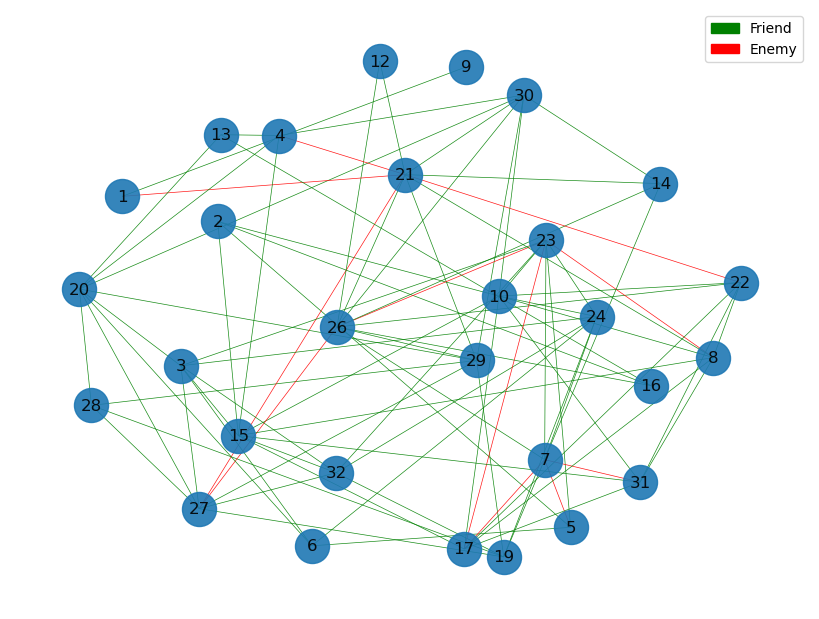

In [16]:
draw_graph(dutch_graphs['t1'], 2)

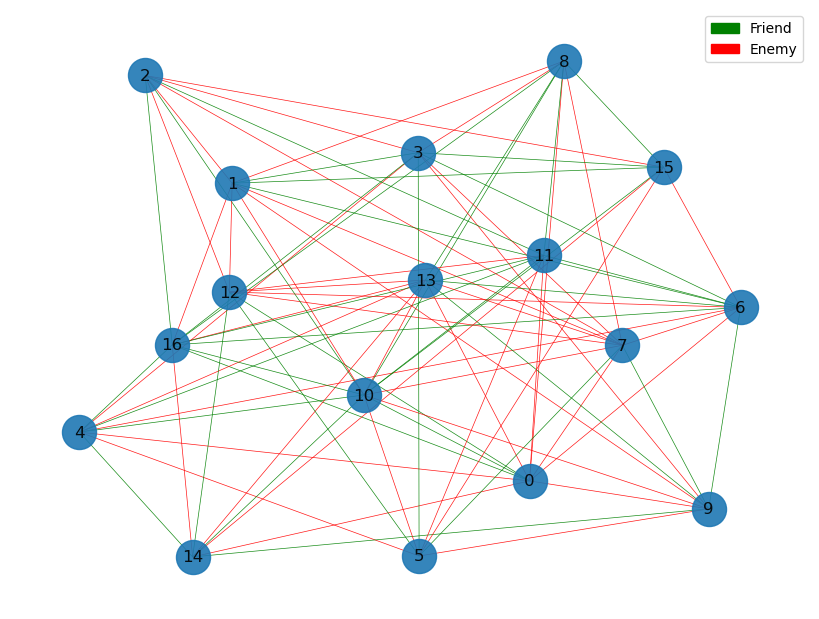

In [17]:
draw_graph(frat_graphs['t0'], 2)

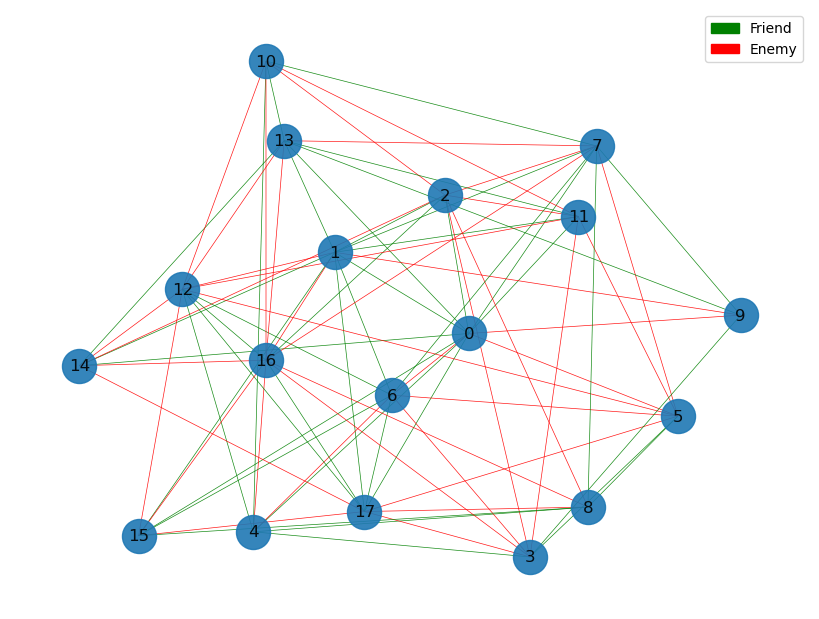

In [18]:
draw_graph(sampson_graphs['T2'], 2)

In [25]:
# CoW country label node lookup dictionary
def cow_node_labels(year):
    return {node: ccode_to_clabel.get(node, str(node)) for node in cow_graphs[year].nodes()}

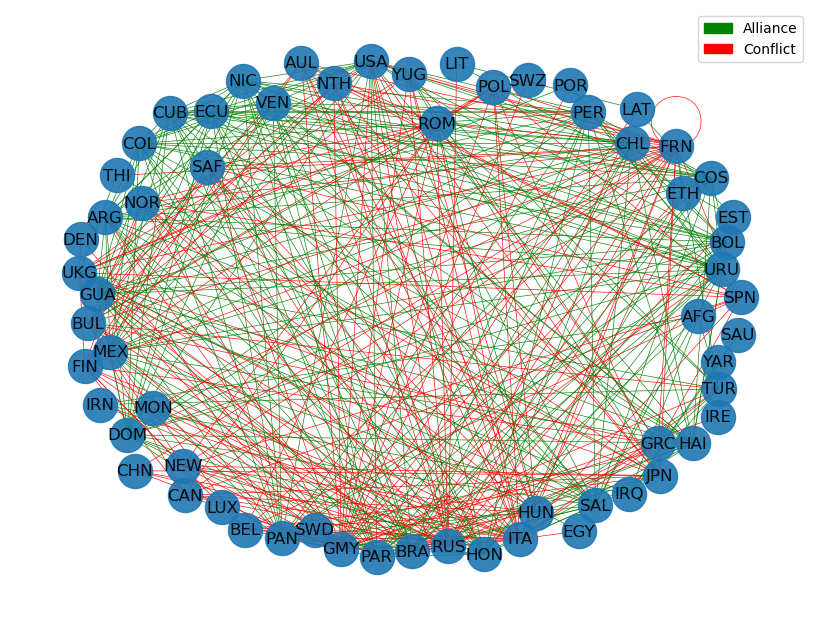

In [26]:
y = 1940
draw_graph(cow_graphs[y], k_val=5, seed=42, year=y, patches='cow')

## Pickle Handoff

In [27]:
# load constructed networks as pickle files to be read in the second jupyter notebook for analysis
datasets = {
    "dutch_graphs.pkl":   dutch_graphs,
    "sampson_graphs.pkl": sampson_graphs,
    "newcomb_graphs.pkl": frat_graphs,
    "cow_graphs_4.pkl":     cow_graphs
}

for fname, graphs in datasets.items():
    with open(fname, "wb") as f:
        pickle.dump(graphs, f)
    print(f"Saved {fname}")

Saved dutch_graphs.pkl
Saved sampson_graphs.pkl
Saved newcomb_graphs.pkl
Saved cow_graphs_4.pkl
